In [ ]:
import torch
import torch.nn as nn

# 해당 layer 만 따로 저장

In [9]:
# a = torch.load('/workspace/eval/training_125000_micro/linear_20epoch/model_final.pth')
# a = torch.load('/workspace/eval/training_157500_micro/linear/running_checkpoint_linear_eval_12500.pth')
# a = torch.load('/workspace/eval/training_125000_micro/linear_50epoch_512/model_final.pth')
# a = torch.load('/workspace/eval/training_125000_micro/linear_50epoch_512/running_checkpoint_linear_eval_37500.pth')
# a = torch.load('/workspace/eval/training_125000_micro/linear_20epoch_gender/running_checkpoint_linear_eval_1250.pth')
# a = torch.load('/workspace/eval/training_125000_micro/linear_20epoch_mse_age/model_final.pth')
# a = torch.load('/workspace/eval/training_125000_micro/linear_3cls/running_checkpoint_linear_eval_8750.pth')
a = torch.load('/workspace/eval/v2_stable_1024_warmup_30/training_625000_new/running_checkpoint_linear_eval_51250.pth')

In [10]:
len(a['model'].keys())

88

In [11]:
from collections import OrderedDict

In [12]:
new = OrderedDict()

In [13]:
for k,v in a['model'].items():
    if 'classifier_1_blocks_avgpool_True_lr_0_00250' in k:
        print(k,v)
        new[k] = v

classifiers_dict.classifier_1_blocks_avgpool_True_lr_0_00250.linear.weight tensor([[-0.0338,  0.0235,  0.0453,  ..., -0.2265,  0.0086, -0.0647],
        [ 0.0394, -0.0421, -0.0819,  ...,  0.2474, -0.0242,  0.0592]],
       device='cuda:0')
classifiers_dict.classifier_1_blocks_avgpool_True_lr_0_00250.linear.bias tensor([-0.0019,  0.0019], device='cuda:0')


In [14]:
new

OrderedDict([('classifiers_dict.classifier_1_blocks_avgpool_True_lr_0_00250.linear.weight',
              tensor([[-0.0338,  0.0235,  0.0453,  ..., -0.2265,  0.0086, -0.0647],
                      [ 0.0394, -0.0421, -0.0819,  ...,  0.2474, -0.0242,  0.0592]],
                     device='cuda:0')),
             ('classifiers_dict.classifier_1_blocks_avgpool_True_lr_0_00250.linear.bias',
              tensor([-0.0019,  0.0019], device='cuda:0'))])

In [16]:
torch.save(new, '/workspace/inference/weights_linear/v2_stable_1024_warmup_30_new/51250_classifier_1_blocks_avgpool_True_lr_0_00250')

In [ ]:
torch.load('/workspace/inference/weights_linear/v2_stable_e400_new/51250_classifier_1_blocks_avgpool_True_lr_0_00500.pth')

OrderedDict([('classifiers_dict.classifier_1_blocks_avgpool_True_lr_0_00500.linear.weight',
              tensor([[ 0.0466, -0.0979, -0.0412,  ...,  0.0515,  0.0293,  0.0181],
                      [-0.0317,  0.0985,  0.0487,  ..., -0.0388, -0.0475,  0.0072]],
                     device='cuda:0')),
             ('classifiers_dict.classifier_1_blocks_avgpool_True_lr_0_00500.linear.bias',
              tensor([ 0.0072, -0.0072], device='cuda:0'))])

In [1]:
import pandas as pd

In [27]:
a = pd.read_csv('/workspace/inference/top_weight_cohort_inference.csv')

In [2]:
from sklearn.metrics import confusion_matrix

In [29]:
cm = confusion_matrix(a['타겟 클래스'],a['예측 클래스'])

In [30]:
cm

array([[744,  40],
       [152, 153]])

In [34]:
# cm = np.array([[TN,FP],
# [FN, TP]])
cm = np.array([[3114,22],
[169, 33]])

In [35]:
import matplotlib.pyplot as plt

def save_confusion_matrix(cm, classes,
                          normalize=False,
                          title='Confusion matrix',
                          cmap=plt.cm.Blues):
    """
    This function prints and plots the confusion matrix.
    Normalization can be applied by setting `normalize=True`.
    """
    
    if normalize:
        cm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

    plt.imshow(cm, interpolation='nearest', cmap=cmap)
    plt.title(title, fontsize='x-large')
    plt.colorbar()
    tick_marks = np.arange(len(classes))
    plt.xticks(tick_marks, classes, fontsize='large')
    plt.yticks(tick_marks, classes, fontsize='large', rotation=90)

    fmt = '.2f' if normalize else 'd'
    thresh = cm.max() / 2.
    for i, j in itertools.product(range(cm.shape[0]), range(cm.shape[1])):
        plt.text(j, i, format(cm[i, j], fmt),
                 horizontalalignment="center",
                 color="white" if cm[i, j] > thresh else "black", size='xx-large')

    plt.tight_layout()
    plt.ylabel('True label', fontsize='large')
    plt.xlabel('Predicted label', fontsize='large')
    # plt.savefig(os.path.join(path_dst,"{}_CM.png".format(taskID)), dpi=300)
    # plt.close("all")
    plt.show()

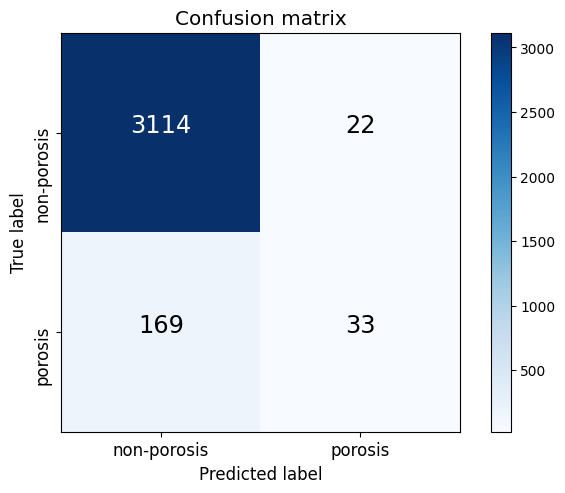

In [36]:
import numpy as np
import itertools
save_confusion_matrix(cm, ['non-porosis','porosis'],
                          normalize=False,
                          title='Confusion matrix',
                          cmap=plt.cm.Blues)

In [72]:
from enum import Enum
from typing import Any, Callable, List, Optional, TypeVar
from typing import Optional, Callable, Any, Tuple
import torch
from torch.utils.data import Sampler
from torchvision.datasets import VisionDataset
from glob import glob 
import numpy as np
from PIL import Image

class SamplerType(Enum):
    DISTRIBUTED = 0
    EPOCH = 1
    INFINITE = 2
    SHARDED_INFINITE = 3
    SHARDED_INFINITE_NEW = 4
    GELEE_TORCH = 5


class osteo(VisionDataset):
    def __init__(
        self,
        *,
        root: str,
        transforms: Optional[Callable] = None,
        transform: Optional[Callable] = None,
        target_transform: Optional[Callable] = None,
    ) -> None:
        super().__init__(root, transforms, transform, target_transform)

        self.root = root 
        print(self.root)
        self.img_lst = glob(root + '/*/*')
        self.class_ = {
                        "normal" : 0,
                        "osteopenia" :0,
                        "osteoporosis":1,
                       }
        self.class_idx = [self.class_[self.img_lst[i].split('/')[-2]] for i in range(len(self.img_lst))]

    def __len__(self) -> int:
        return len(self.img_lst)  

    def __getitem__(self, index: int) -> Tuple[Any, Any]:
        try:
            image_data = Image.open(self.img_lst[index]).convert(mode="RGB")
            # image = ImageDataDecoder(image_data).decode()
        except Exception as e:
            raise RuntimeError(f"can not read image for sample {index}") from e
        
        target = self.class_idx[index]
        # target = TargetDecoder(target).decode()

        if self.transforms is not None:
            # image = self.transforms(image=image_data)['image'] # albumentations 에러뜸
            image, target = self.transforms(image_data, target) # torchvision transforms
            
        return image, target


def _parse_dataset_str(dataset_str: str):
    tokens = dataset_str.split(":")

    name = tokens[0]
    kwargs = {}

    for token in tokens[1:]:
        key, value = token.split("=")
        assert key in ("root", "extra", "split")
        kwargs[key] = value

    name = "osteo"
    class_ = osteo
    return class_, kwargs



def make_dataset(
    *,
    dataset_str: str,
    transform: Optional[Callable] = None,
    target_transform: Optional[Callable] = None,
):
    """
    Creates a dataset with the specified parameters.

    Args:
        dataset_str: A dataset string description (e.g. ImageNet:split=TRAIN).
        transform: A transform to apply to images.
        target_transform: A transform to apply to targets.

    Returns:
        The created dataset.
    """

    class_, kwargs = _parse_dataset_str(dataset_str)
    dataset = class_(transform=transform, target_transform=target_transform, **kwargs)

    # Aggregated datasets do not expose (yet) these attributes, so add them.
    if not hasattr(dataset, "transform"):
        setattr(dataset, "transform", transform)
    if not hasattr(dataset, "target_transform"):
        setattr(dataset, "target_transform", target_transform)

    return dataset

## 추가: 가은님 토치모델 샘플러
def make_weights_for_balanced_classes(classes):
    """
        classes : 0부터 시작하는 class index.
    """
    nclasses = len(set(classes))
    count = [0] * nclasses                                                      
    for cl in classes:                                                         
        count[cl] += 1                                                     
    weight_per_class = [0.] * nclasses                                      
    N = float(sum(count))                                                   
    for i in range(nclasses):                                                   
        weight_per_class[i] = N/float(count[i])                                 
    weight = [0] * len(classes)                                              
    for idx, cl in enumerate(classes):                                          
        weight[idx] = weight_per_class[cl]                                  
    return weight 

def _make_sampler(
    *,
    dataset,
    type: Optional[SamplerType] = None,
    shuffle: bool = False,
    seed: int = 0,
    size: int = -1,
    advance: int = 0,
) -> Optional[Sampler]:
    sample_count = len(dataset)

    if type == SamplerType.INFINITE:
        if size > 0:
            raise ValueError("sampler size > 0 is invalid")
        return InfiniteSampler(
            sample_count=sample_count,
            shuffle=shuffle,
            seed=seed,
            advance=advance,
        )
    
    elif type == SamplerType.GELEE_TORCH:
        weights = make_weights_for_balanced_classes(dataset.class_idx)
        weights = torch.DoubleTensor(weights)  
        return torch.utils.data.sampler.WeightedRandomSampler(weights, len(weights))      

    return None

T = TypeVar("T")

def make_data_loader(
    *,
    dataset,
    batch_size: int,
    num_workers: int,
    shuffle: bool = True,
    seed: int = 0,
    sampler_type: Optional[SamplerType] = SamplerType.INFINITE,
    sampler_size: int = -1,
    sampler_advance: int = 0,
    drop_last: bool = True,
    persistent_workers: bool = False,
    collate_fn: Optional[Callable[[List[T]], Any]] = None,
):
    """
    Creates a data loader with the specified parameters.

    Args:
        dataset: A dataset (third party, LaViDa or WebDataset).
        batch_size: The size of batches to generate.
        num_workers: The number of workers to use.
        shuffle: Whether to shuffle samples.
        seed: The random seed to use.
        sampler_type: Which sampler to use: EPOCH, INFINITE, SHARDED_INFINITE, SHARDED_INFINITE_NEW, DISTRIBUTED or None.
        sampler_size: The number of images per epoch (when applicable) or -1 for the entire dataset.
        sampler_advance: How many samples to skip (when applicable).
        drop_last: Whether the last non-full batch of data should be dropped.
        persistent_workers: maintain the workers Dataset instances alive after a dataset has been consumed once.
        collate_fn: Function that performs batch collation
    """

    sampler = _make_sampler(
        dataset=dataset,
        type=sampler_type,
        shuffle=shuffle,
        seed=seed,
        size=sampler_size,
        advance=sampler_advance,
    )

    data_loader = torch.utils.data.DataLoader(
        dataset,
        sampler=sampler,
        batch_size=batch_size,
        num_workers=num_workers,
        pin_memory=True,
        drop_last=drop_last,
        persistent_workers=persistent_workers,
        collate_fn=collate_fn,
    )

    return data_loader



In [83]:
from torchvision import transforms
from typing import Sequence
from PIL import ImageEnhance, Image, ImageFilter
import random

IMAGENET_DEFAULT_MEAN = (0.485, 0.456, 0.406)
IMAGENET_DEFAULT_STD = (0.229, 0.224, 0.225)

class MaybeToTensor(transforms.ToTensor):
    """
    Convert a ``PIL Image`` or ``numpy.ndarray`` to tensor, or keep as is if already a tensor.
    """

    def __call__(self, pic):
        """
        Args:
            pic (PIL Image, numpy.ndarray or torch.tensor): Image to be converted to tensor.
        Returns:
            Tensor: Converted image.
        """
        if isinstance(pic, torch.Tensor):
            return pic
        return super().__call__(pic)

def make_normalize_transform(
    mean: Sequence[float] = IMAGENET_DEFAULT_MEAN,
    std: Sequence[float] = IMAGENET_DEFAULT_STD,
) -> transforms.Normalize:
    return transforms.Normalize(mean=mean, std=std)


def srpark_make_classification_train_transform(
    *,
    crop_size: int = 512,
    interpolation=transforms.InterpolationMode.BICUBIC,
    hflip_prob: float = 0.5,
    mean: Sequence[float] = IMAGENET_DEFAULT_MEAN,
    std: Sequence[float] = IMAGENET_DEFAULT_STD,
):
    # transforms_list = [transforms.RandomResizedCrop(crop_size, interpolation=interpolation)]
    transforms_list = [transforms.Resize(crop_size, interpolation=interpolation)]
    transforms_list.append(transforms.CenterCrop(crop_size))
    if hflip_prob > 0.0:
        transforms_list.append(transforms.RandomHorizontalFlip(hflip_prob))
    transforms_list.extend(
        [
            MaybeToTensor(),
            make_normalize_transform(mean=mean, std=std),
        ]
    )
    
    return transforms.Compose(transforms_list)

In [84]:
train_transform = srpark_make_classification_train_transform()
train_dataset = make_dataset(
    dataset_str='osteo:root=/workspace/osteo_dataset/labelV6_AMC_FM_3cls/train',
    transform=train_transform,
)
training_num_classes = 2 #len(torch.unique(torch.Tensor(train_dataset.get_targets().astype(int))))


/workspace/osteo_dataset/labelV6_AMC_FM_3cls/train


In [85]:
len(train_dataset.class_idx)

54769

In [86]:
weights = make_weights_for_balanced_classes(train_dataset.class_idx)
weights = torch.DoubleTensor(weights)  


In [87]:
sampler_type = SamplerType.GELEE_TORCH

In [94]:
train_data_loader = make_data_loader(
        dataset=train_dataset,
        batch_size=10,
        num_workers=2,
        shuffle=True,
        seed=2,
        sampler_type=sampler_type,
        drop_last=True,
        persistent_workers=True,
    )

In [95]:
a = next(iter(train_data_loader))

In [96]:
a

[tensor([[[[-2.1179, -2.1179, -2.1179,  ..., -2.1179, -2.1179, -2.1179],
           [-2.1179, -2.1179, -2.1179,  ..., -2.1179, -2.1179, -2.1179],
           [-2.1179, -2.1179, -2.1179,  ..., -2.1179, -2.1179, -2.1179],
           ...,
           [-0.4397, -0.6281, -0.7822,  ..., -2.1179, -2.1179, -2.1179],
           [-0.3883, -0.5938, -0.7479,  ..., -2.1179, -2.1179, -2.1179],
           [-0.3883, -0.5938, -0.7479,  ..., -2.1179, -2.1179, -2.1179]],
 
          [[-2.0357, -2.0357, -2.0357,  ..., -2.0357, -2.0357, -2.0357],
           [-2.0357, -2.0357, -2.0357,  ..., -2.0357, -2.0357, -2.0357],
           [-2.0357, -2.0357, -2.0357,  ..., -2.0357, -2.0357, -2.0357],
           ...,
           [-0.3200, -0.5126, -0.6702,  ..., -2.0357, -2.0357, -2.0357],
           [-0.2675, -0.4776, -0.6352,  ..., -2.0357, -2.0357, -2.0357],
           [-0.2675, -0.4776, -0.6352,  ..., -2.0357, -2.0357, -2.0357]],
 
          [[-1.8044, -1.8044, -1.8044,  ..., -1.8044, -1.8044, -1.8044],
           [-